Here, I test local hopping of ISs based on Lee et al. NAR 2016.

I generate random insertion data set, compare with our results with AD test, and combine them with Fisher's method.

Note that simple insertions here include simple transpositions, where a composite transposition is inserted without other SVs.
For instance, as follows:

```Julia
			inserts_df_simple_ = @chain inserts_df_ begin
				@rsubset :sv in ["simple_insertion", "simple_transposition"]
			end
```

Insertions are based on the `cluster_id`.
This ID was given based on hierarchical clustering of all ISs 
ISs in a genome mapped on to the genome of its predecessor and the ISs in the predecessor genome.
This naturally avoids double counting of both IS ends (as they are typically within the cluster size)
and IS insertions within duplication regions (as they would belong to the same cluster).

# Overview 
1. load data
2. calculate ECDF
3. analyze KS-tests + plot qq plots
4. analyze AD-tests + Fishers tests
5. aggregate all the plots into one-page figure

# Load data

In [1]:
import Pkg
using RCall
using Random
using DataFrames, DataFramesMeta
using Revise
using CSV
using Arrow

In [2]:
# made tables in Excel by C&P from the Supplementary PDF
original_pos_df = CSV.read("../misc/Lee2016/MG1655_IS_pos.csv", DataFrame)
deletions_df = CSV.read("../misc/Lee2016/S7.csv", DataFrame)
insertions_df = CSV.read("../misc/Lee2016/S8.csv", DataFrame)
genome_size = 4641652  # MG1655

4641652

In [3]:
first(original_pos_df, 2) |> display
first(deletions_df, 2) |> display
first(insertions_df, 2) |> display

Row,IS,Length,Start,End
,String7,Int64,Int64,Int64
1,IS1A,768,1979270,1978503
2,IS1A,768,3583428,3584195


Row,Type,Line,IS,Size,Start,End,CP4-6
,String3,String15,String7,Int64,Int64,Int64,String3?
1,E+E,mutL54,IS5A,35594,2065377,21009678,missing
2,E+N,wt70,IS5A,35580,274375,309954,missing


Row,IS,Line,Strand,Position,Gene
,String7,String15,String1,Int64,String7
1,IS1A,M180-27,+,7594,yaaJ
2,IS1A,M101-037,-,11035,yaaW


In [4]:
# get the circular distances from original pos
function circular_distance(a, b, genome_size)
	return min(abs(a - b), genome_size - abs(a - b))
end

# identify the closest distance and the associated type
# initialize cols closest_original_id	closest_original_distance sv_type
insertions_df[!, :closest_original_id] .= 0
insertions_df[!, :closest_original_pos] .= 0
insertions_df[!, :closest_original_distance] .= 0
insertions_df[!, :sv_type] .= ""
insertions_df[!, :del_ID] .= 0

deletions_df[!, :del_ID] .= 1:nrow(deletions_df)
deletions_df = @subset(deletions_df, :IS .∈ Ref(["IS1A", "IS2", "IS5A"]))

for i in 1:nrow(insertions_df)
    row = insertions_df[i, :]
    
    sub_df = @subset(original_pos_df, :IS .== row.IS)
    if nrow(sub_df) == 0
        continue
    end
    
    distances_start = circular_distance.(sub_df.Start, row.Position, genome_size)
    distances_end = circular_distance.(sub_df.End, row.Position, genome_size)

    closest_original_distance_S, idx_S = findmin(distances_start)
    closest_original_distance_E, idx_E = findmin(distances_end)

    if closest_original_distance_S < closest_original_distance_E
        closest_original_distance = closest_original_distance_S
        closest_original_id = idx_S
        closest_original_pos = sub_df.Start[closest_original_id]
    else
        closest_original_distance = closest_original_distance_E
        closest_original_id = idx_E
        closest_original_pos = sub_df.End[closest_original_id]
    end

    insertions_df[i, :closest_original_id] = closest_original_id
    insertions_df[i, :closest_original_distance] = closest_original_distance
    insertions_df[i, :closest_original_pos] = closest_original_pos

    # Check for matching deletion event
    sub_df2 = @subset(deletions_df, :IS .== row.IS, :Line .== row.Line)
    # if either Start or End matches the position
    sub_df2 = @subset(sub_df2, (:Start .== row.Position) .| (:End .== row.Position))
    if nrow(sub_df2) > 0
        insertions_df[i, :sv_type] = sub_df2.Type[1]
        insertions_df[i, :del_ID] = sub_df2.del_ID[1]
    end
end

first(insertions_df, 5)

Row,IS,Line,Strand,Position,Gene,closest_original_id,closest_original_pos,closest_original_distance,sv_type,del_ID
,String7,String15,String1,Int64,String7,Int64,Int64,Int64,String,Int64
1,IS1A,M180-27,+,7594,yaaJ,3,279163,271569,,0
2,IS1A,M101-037,-,11035,yaaW,3,279163,268128,,0
3,IS1A,M35-009,-,42482,fixA,3,279163,236681,,0
4,IS1A,M88-19,+,75303,thiB,3,279163,203860,N+N,40
5,IS1A,M88-44,-,83776,NC,3,279163,195387,,0


In [6]:
n_ee = size(@subset(deletions_df, :Type .== "E+E"))[1]
n_en = size(@subset(deletions_df, :Type .== "E+N"))[1]
n_nn = size(@subset(deletions_df, :Type .== "N+N"))[1]
println("EE: $n_ee, EN: $n_en, NN: $n_nn")
println("Expected insertion counts:$(n_en + 2n_nn)")

EE: 14, EN: 71, NN: 12
Expected insertion counts:95


### Analysis of inconsistencies.
ID 39 is a deletion that includes a pre-existing IS.
I ignore this as in my study, I would classify it as non-IS deletion.

ID 67 is a N-N type insertion.
I think this there is a typo, where Line M133-133 in Table S8 should be M133-113.

In [9]:
en_ID = deletions_df[deletions_df.Type .== "E+N", :del_ID]
nn_ID = deletions_df[deletions_df.Type .== "N+N", :del_ID]

found_ID = insertions_df[insertions_df.sv_type .!= "", :del_ID]
missing_ID = setdiff(union(en_ID, nn_ID), found_ID)

println("Found counts:$(size(found_ID)[1])")
println("Missing counts:$(size(missing_ID)[1])")
missing_ID

Found counts:92
Missing counts:2


2-element Vector{Int64}:
 39
 67

In [11]:
deletions_df[in.(deletions_df.del_ID, Ref(missing_ID)), :]

Row,Type,Line,IS,Size,Start,End,CP4-6,del_ID
,String3,String15,String7,Int64,Int64,Int64,String3?,Int64
1,E+N,M88-17,IS1A,7401,1977460,1984904,missing,39
2,N+N,M133-113,IS1A,162,2379405,2379567,missing,67


In [12]:
# This one seems to be an IS loss due to deleting sequence including the IS
# That is why it is not included in the insertions
@subset(insertions_df, :Position .== 1984904) |> display
@subset(insertions_df, :Position .== 2379405) |> display
@subset(insertions_df, :Position .== 2379567) |> display

Row,IS,Line,Strand,Position,Gene,closest_original_id,closest_original_pos,closest_original_distance,sv_type,del_ID
,String7,String15,String1,Int64,String7,Int64,Int64,Int64,String,Int64


Row,IS,Line,Strand,Position,Gene,closest_original_id,closest_original_pos,closest_original_distance,sv_type,del_ID
,String7,String15,String1,Int64,String7,Int64,Int64,Int64,String,Int64
1,IS1A,M133-133,+,2379405,elaA,1,1979270,400135,,0


Row,IS,Line,Strand,Position,Gene,closest_original_id,closest_original_pos,closest_original_distance,sv_type,del_ID
,String7,String15,String1,Int64,String7,Int64,Int64,Int64,String,Int64
1,IS1A,M133-133,+,2379567,NC,1,1979270,400297,,0


In [21]:
@subset(insertions_df, :Line .== "M88-17")

Row,IS,Line,Strand,Position,Gene,closest_original_id,closest_original_pos,closest_original_distance,sv_type,del_ID
,String7,String15,String1,Int64,String7,Int64,Int64,Int64,String,Int64
1,IS1A,M88-17,+,1696213,malI,1,1978503,282290,,0
2,IS1A,M88-17,+,2421159,yfcI,1,1979270,441889,,0
3,IS2,M88-17,+,310225,matA,1,381260,71035,,0
4,IS5A,M88-17,-,316004,NC,1,275149,40855,,0


In [23]:
(@subset(insertions_df, :Line .== "M133-133"))

Row,IS,Line,Strand,Position,Gene,closest_original_id,closest_original_pos,closest_original_distance,sv_type,del_ID
,String7,String15,String1,Int64,String7,Int64,Int64,Int64,String,Int64
1,IS1A,M133-133,+,2379405,elaA,1,1979270,400135,,0
2,IS1A,M133-133,+,2379567,NC,1,1979270,400297,,0


In [24]:
insertions_df[insertions_df.Line .== "M133-133", :sv_type] .= "N+N"
insertions_df[insertions_df.Line .== "M133-133", :del_ID] .= 67
(@subset(insertions_df, :Line .== "M133-133"))

Row,IS,Line,Strand,Position,Gene,closest_original_id,closest_original_pos,closest_original_distance,sv_type,del_ID
,String7,String15,String1,Int64,String7,Int64,Int64,Int64,String,Int64
1,IS1A,M133-133,+,2379405,elaA,1,1979270,400135,N+N,67
2,IS1A,M133-133,+,2379567,NC,1,1979270,400297,N+N,67


###

## Run the analysis

In [35]:
run_num = "14"
figure_export_dir = "./exp/multiple_runs$run_num/figs/analyze_is_distance/Lee2016"
data_export_dir = "./analyze_is_distance_$run_num"
figure_prefix = "20250204_Lee2016_"
mkpath(figure_export_dir)
mkpath(data_export_dir)

"./analyze_is_distance_14"

# Create ECDF data sets

In [28]:
function circular_dicstance(x, y, genome_size)
	min(abs(x - y), genome_size - abs(x - y))
end

function generate_random_insretion_distances(is_pos_list, genome_size, n, rng)
	inserts = rand(rng, 1:genome_size, n)
	closest_is = zeros(Int64, n)
	distance = zeros(Int64, n)
	for i in 1:n
		distance[i], closest_is[i] = findmin(map(x -> circular_dicstance(x, inserts[i], genome_size), is_pos_list))
	end
	return inserts, closest_is, distance
end

function generate_random_insretion_distances(is_start, is_end, genome_size, n, rng)
	inserts = rand(rng, 1:genome_size, n)
	closest_is = repeat([-1], n)
	distance = repeat([-1], n)
	for i in 1:n
		distance_s, closest_is_s = findmin(map(x -> circular_dicstance(x, inserts[i], genome_size), is_start))
		distance_e, closest_is_e = findmin(map(x -> circular_dicstance(x, inserts[i], genome_size), is_end))
		distance[i] = min(distance_s, distance_e)
		closest_is[i] = distance_s < distance_e ? closest_is_s : closest_is_e
		if is_start[closest_is[i]] <= inserts[i] <= is_end[closest_is[i]]
			distance[i] = 0
		end
	end
	return inserts, closest_is, distance
end

generate_random_insretion_distances (generic function with 2 methods)

In [29]:
function ECDF(data)
    n = length(data)
    x = sort(data)
    y = collect(1:1:n)/n
    return(x,y)
end

ECDF (generic function with 1 method)

### ECDF of null-model

In [31]:
# Calculate the ecdf for random insertions 
estimated_is_pos_df = DataFrame()
ecdf_df = DataFrame()
seed = 1234
rng = Random.MersenneTwister(seed)

ISs = ["IS1A", "IS2", "IS5A"]
arrow_dir = joinpath(data_export_dir, "simulated_IS_distances_MG1655.arrow")

if isfile(arrow_dir)
	ecdf_df = Arrow.Table(arrow_dir) |> DataFrame
else
	for IS in ISs
		is_pos_list_anc = original_pos_df[original_pos_df.IS .== IS, :]
		res_ = generate_random_insretion_distances(
			is_pos_list_anc.Start, is_pos_list_anc.End, genome_size, 10000, rng)

		estimated_is_pos_df_raw = DataFrame(
			IS = repeat([IS], 10000),
			Insertion = res_[1],
			Closest_IS = res_[2],
			Distance = res_[3]
		)

		# <100 for consistency with my study
		estimated_is_pos_df_raw = estimated_is_pos_df_raw[estimated_is_pos_df_raw.Distance .> 100, :]
		estimated_is_pos_df = vcat(estimated_is_pos_df, estimated_is_pos_df_raw)
		ecdf = ECDF(estimated_is_pos_df_raw.Distance)
		ecdf_df = vcat(ecdf_df,DataFrame(
			IS = repeat([IS], length(ecdf[1])),
			Distance = ecdf[1],
			ECDF = ecdf[2])
		)
		println("Finished $IS")
	end
	Arrow.write(arrow_dir, ecdf_df)
end
ecdf_df |> x -> first(x, 5)

Finished IS1A
Finished IS2
Finished IS5A


Row,IS,Distance,ECDF
,String,Int64,Float64
1,IS1A,101,0.00010007
2,IS1A,126,0.00020014
3,IS1A,130,0.00030021
4,IS1A,144,0.00040028
5,IS1A,192,0.00050035


### ECDF of real data (1: all data)

In [32]:
# Calculate the ecdf for random insertions 
estimated_is_pos_df = DataFrame()
observed_ecdf_df = DataFrame()
seed = 1234
rng = Random.MersenneTwister(seed)

ISs = ["IS1A", "IS2", "IS5A"]
arrow_dir = joinpath(data_export_dir, "all_observed_IS_distances_MG1655.arrow")

if false #isfile(arrow_dir)
	observed_ecdf_df = Arrow.Table(arrow_dir) |> DataFrame
else
	for IS in ISs
		is_pos_list_anc = original_pos_df[original_pos_df.IS .== IS, :]
		res_ = generate_random_insretion_distances(
			is_pos_list_anc.Start, is_pos_list_anc.End, genome_size, 10000, rng)

		insertions_df_IS = @subset(insertions_df, :IS .== IS)
		n_row = size(insertions_df_IS)[1]

		estimated_is_pos_df_raw = DataFrame(
			IS = repeat([IS], n_row),
			Insertion = insertions_df_IS.Position,
			Closest_IS = insertions_df_IS.closest_original_id,
			Distance = insertions_df_IS.closest_original_distance
		)

		# <100 for consistency with my study
		estimated_is_pos_df_raw = estimated_is_pos_df_raw[estimated_is_pos_df_raw.Distance .> 100, :]
		estimated_is_pos_df = vcat(estimated_is_pos_df, estimated_is_pos_df_raw)
		ecdf = ECDF(estimated_is_pos_df_raw.Distance)
		observed_ecdf_df = vcat(observed_ecdf_df,DataFrame(
			IS = repeat([IS], length(ecdf[1])),
			Distance = ecdf[1],
			ECDF = ecdf[2])
		)
		println("Finished $IS")
	end
	Arrow.write(arrow_dir, observed_ecdf_df)
end
observed_ecdf_df |> x -> first(x, 5)

Finished IS1A
Finished IS2
Finished IS5A


Row,IS,Distance,ECDF
,String,Int64,Float64
1,IS1A,198,0.00429185
2,IS1A,363,0.00858369
3,IS1A,464,0.0128755
4,IS1A,648,0.0171674
5,IS1A,1652,0.0214592


In [38]:
# Calculate the ecdf for random insertions 
estimated_is_pos_df = DataFrame()
observed_ecdf_simple_df = DataFrame()
seed = 1234
rng = Random.MersenneTwister(seed)

ISs = ["IS1A", "IS2", "IS5A"]
arrow_dir = joinpath(data_export_dir, "simple_observed_IS_distances_MG1655.arrow")

if false #isfile(arrow_dir)
	observed_ecdf_simple_df = Arrow.Table(arrow_dir) |> DataFrame
else
	for IS in ISs
		is_pos_list_anc = original_pos_df[original_pos_df.IS .== IS, :]
		res_ = generate_random_insretion_distances(
			is_pos_list_anc.Start, is_pos_list_anc.End, genome_size, 10000, rng)

		insertions_df_IS = @subset(insertions_df, :IS .== IS, :sv_type .== "")
		n_row = size(insertions_df_IS)[1]

		estimated_is_pos_df_raw = DataFrame(
			IS = repeat([IS], n_row),
			Insertion = insertions_df_IS.Position,
			Closest_IS = insertions_df_IS.closest_original_id,
			Distance = insertions_df_IS.closest_original_distance
		)

		# <100 for consistency with my study
		estimated_is_pos_df_raw = estimated_is_pos_df_raw[estimated_is_pos_df_raw.Distance .> 100, :]
		estimated_is_pos_df = vcat(estimated_is_pos_df, estimated_is_pos_df_raw)
		ecdf = ECDF(estimated_is_pos_df_raw.Distance)
		observed_ecdf_simple_df = vcat(observed_ecdf_simple_df,DataFrame(
			IS = repeat([IS], length(ecdf[1])),
			Distance = ecdf[1],
			ECDF = ecdf[2])
		)
		println("Finished $IS")
	end
	Arrow.write(arrow_dir, observed_ecdf_simple_df)
end
observed_ecdf_simple_df |> x -> first(x, 5)

Finished IS1A
Finished IS2
Finished IS5A


Row,IS,Distance,ECDF
,String,Int64,Float64
1,IS1A,464,0.00512821
2,IS1A,1652,0.0102564
3,IS1A,2846,0.0153846
4,IS1A,11801,0.0205128
5,IS1A,18310,0.025641


# Plot the results

In [34]:
R"""
library(tidyverse)
library(cowplot)
library(latex2exp)
library(stats)
cbp <- c("#999999", "#E69F00", "#56B4E9", "#009E73", 
                       "#F0E442", "#0072B2", "#D55E00", "#CC79A7")
"""

┌ Warning: RCall.jl: ── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
│ ✔ dplyr     1.1.3     ✔ readr     2.1.4
│ ✔ forcats   1.0.0     ✔ stringr   1.5.0
│ ✔ ggplot2   3.4.3     ✔ tibble    3.2.1
│ ✔ lubridate 1.9.2     ✔ tidyr     1.3.0
│ ✔ purrr     1.0.2     
│ ── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
│ ✖ dplyr::filter() masks stats::filter()
│ ✖ dplyr::lag()    masks stats::lag()
│ ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172
┌ Warning: RCall.jl: 
│ Attaching package: ‘cowplot’
│ 
│ The following object is masked from ‘package:lubridate’:
│ 
│     stamp
│ 
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


RObject{StrSxp}
[1] "#999999" "#E69F00" "#56B4E9" "#009E73" "#F0E442" "#0072B2" "#D55E00"
[8] "#CC79A7"


┌ Warning: RCall.jl: Warning in RColorBrewer::brewer.pal(2, "Set1") :
│   minimal value for n is 3, returning requested palette with 3 different levels
│ 
└ @ RCall ~/.julia/packages/RCall/gOwEW/src/io.jl:172


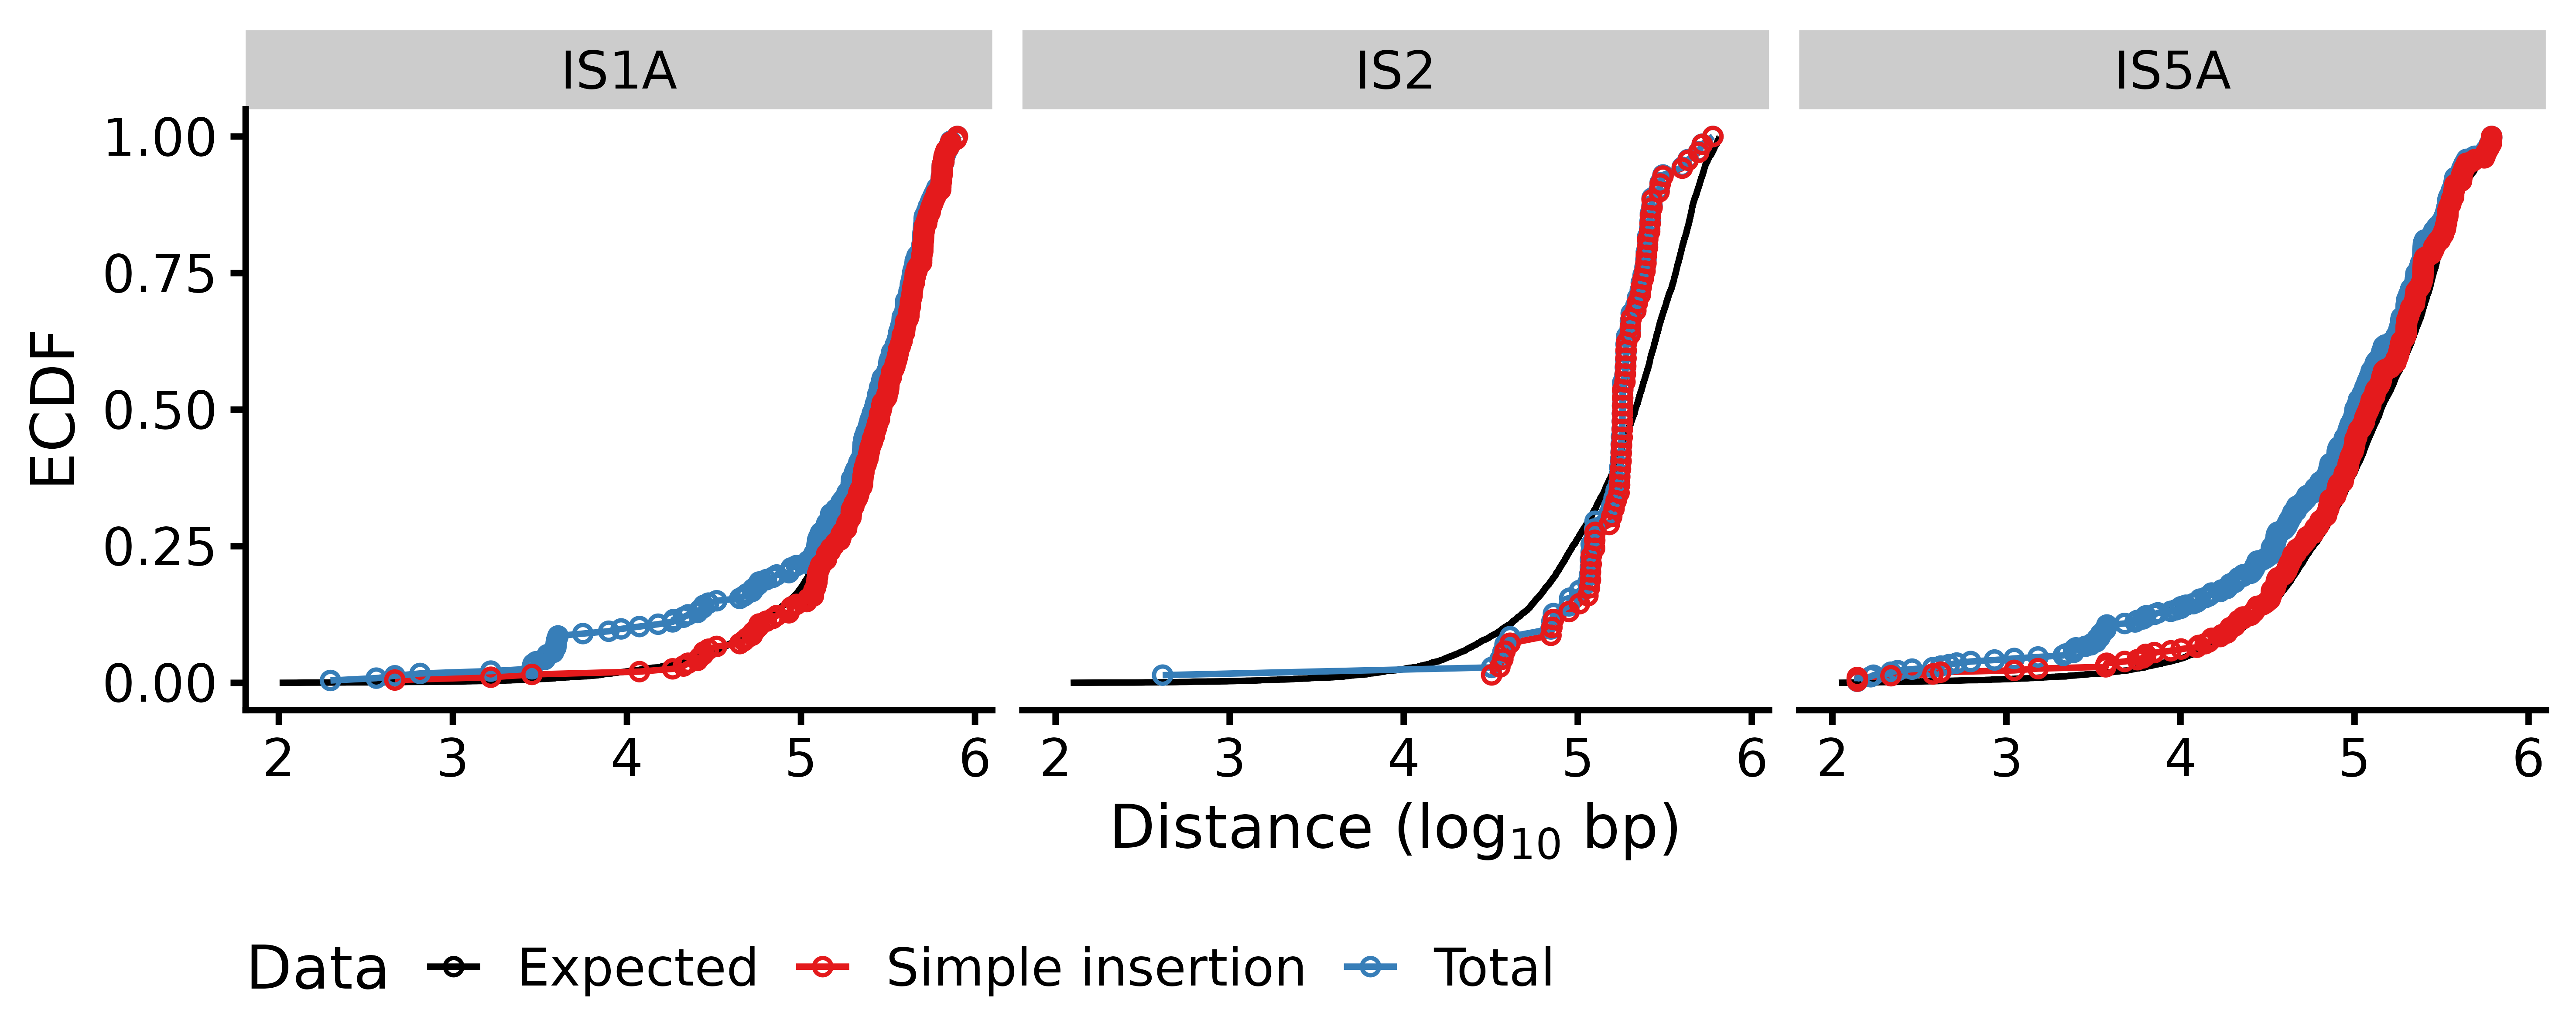

In [53]:
figure_name = figure_prefix * "is_distance_ecdf_gen2"
@rput ecdf_df #MG1655
@rput observed_ecdf_df
@rput observed_ecdf_simple_df
@rput figure_name
@rput figure_export_dir
R"""
Sys.setlocale("LC_COLLATE","C") # order by dictionary order
library(scales)
library(lemon)

ecdf2 <- ecdf_df
ecdf2["Data"] <- "Expected"
observed_ecdf_df["Data"] <- "Total "
observed_ecdf_simple_df["Data"] <- "Simple insertion"
cols <- c("black", RColorBrewer::brewer.pal(2, "Set1"))
merged_df <- ecdf2 %>% rbind(observed_ecdf_df) %>% rbind(observed_ecdf_simple_df)

p <- merged_df %>%
	ggplot(aes(x = log10(Distance), y = ECDF, color = Data)) +
	geom_line(size = .5) +
	geom_point(data=merged_df %>% filter(Data!="Expected"), size=1, shape =1) +
	labs(x = TeX("Distance ($log_{10}$ bp)"), y = "ECDF") +
	 scale_color_manual(values = cols)+
	facet_wrap(~IS)+
	theme_half_open(10)+
	theme(legend.direction = "horizontal", legend.position = "bottom")

ggsave(paste0(figure_export_dir,"/", figure_name, ".png"), p, width=150, height=60, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".svg"), p, width=150, height=60, units="mm", dpi=1000)
ggsave(paste0(figure_export_dir,"/", figure_name, ".pdf"), p, width=150, height=60, units="mm", dpi=1000)

p.ecdf.IS <- p
"""
display("image/png", read(joinpath(figure_export_dir, figure_name * ".png")))

# Stats
Just run Anderson-darling

# Run AD-test and combine with fisher
The distribution of qqplot and the interpretation of Lee, 2016 suggests that the shorter tail is important. AD tests are more suitable than KS in this case, so though qualitatively the same, I used AD tests instead in the paper.

In [54]:
using HypothesisTests

adtests = DataFrame(
	IS = String[],
	pvalue = Float64[],
	type = String[]
)

for IS in ISs
	ecdf_IS = @subset(observed_ecdf_df, :IS .== IS)
	ecdf_IS_simple = @subset(observed_ecdf_simple_df, :IS .== IS)
	ecdf_IS_exp = @subset(ecdf_df, :IS .== IS)

	adtest = HypothesisTests.KSampleADTest(ecdf_IS.Distance, ecdf_IS_exp.Distance)
	display(adtest)
	push!(adtests, [IS, pvalue(adtest), "Total Transposition"])

	adtest_simple = HypothesisTests.KSampleADTest(ecdf_IS_simple.Distance, ecdf_IS_exp.Distance)
	push!(adtests, [IS, pvalue(adtest_simple), "Simple Insertion"])
	display(adtest_simple)
end

adtests

k-sample Anderson-Darling test
------------------------------
Population details:
    parameter of interest:   not implemented yet
    value under h_0:         NaN
    point estimate:          NaN

Test summary:
    outcome with 95% confidence: reject h_0
    one-sided p-value:           0.0035

Details:
    number of samples:        2
    number of observations:   10226
    SD of A²k:                0.7615982226379988
    A²k statistic:            4.8225681655112265
    standardized statistic:   5.019140081854105
    modified test:            true
    p-value calculation:      asymptotic


k-sample Anderson-Darling test
------------------------------
Population details:
    parameter of interest:   not implemented yet
    value under h_0:         NaN
    point estimate:          NaN

Test summary:
    outcome with 95% confidence: fail to reject h_0
    one-sided p-value:           0.6495

Details:
    number of samples:        2
    number of observations:   10188
    SD of A²k:                0.7616684122277216
    A²k statistic:            0.597404303946111
    standardized statistic:   -0.528570818469917
    modified test:            true
    p-value calculation:      asymptotic


k-sample Anderson-Darling test
------------------------------
Population details:
    parameter of interest:   not implemented yet
    value under h_0:         NaN
    point estimate:          NaN

Test summary:
    outcome with 95% confidence: reject h_0
    one-sided p-value:           0.0004

Details:
    number of samples:        2
    number of observations:   10056
    SD of A²k:                0.7624243927434718
    A²k statistic:            6.660380168308814
    standardized statistic:   7.4241855614571435
    modified test:            true
    p-value calculation:      asymptotic


k-sample Anderson-Darling test
------------------------------
Population details:
    parameter of interest:   not implemented yet
    value under h_0:         NaN
    point estimate:          NaN

Test summary:
    outcome with 95% confidence: reject h_0
    one-sided p-value:           0.0004

Details:
    number of samples:        2
    number of observations:   10054
    SD of A²k:                0.7624589045218527
    A²k statistic:            6.713312904484537
    standardized statistic:   7.493273238204786
    modified test:            true
    p-value calculation:      asymptotic


k-sample Anderson-Darling test
------------------------------
Population details:
    parameter of interest:   not implemented yet
    value under h_0:         NaN
    point estimate:          NaN

Test summary:
    outcome with 95% confidence: reject h_0
    one-sided p-value:           <1e-08

Details:
    number of samples:        2
    number of observations:   10349
    SD of A²k:                0.7614727111154157
    A²k statistic:            17.99251927365636
    standardized statistic:   22.315335829652362
    modified test:            true
    p-value calculation:      asymptotic


k-sample Anderson-Darling test
------------------------------
Population details:
    parameter of interest:   not implemented yet
    value under h_0:         NaN
    point estimate:          NaN

Test summary:
    outcome with 95% confidence: fail to reject h_0
    one-sided p-value:           0.0558

Details:
    number of samples:        2
    number of observations:   10297
    SD of A²k:                0.7615118014558169
    A²k statistic:            2.4018692858608888
    standardized statistic:   1.840902902858329
    modified test:            true
    p-value calculation:      asymptotic


Row,IS,pvalue,type
,String,Float64,String
1,IS1A,0.00349713,Total Transposition
2,IS1A,0.649541,Simple Insertion
3,IS2,0.000444614,Total Transposition
4,IS2,0.000418829,Simple Insertion
5,IS5A,2.13316e-9,Total Transposition
6,IS5A,0.0558379,Simple Insertion
